# Commercial POI Clustering and Street Network Structure in Central Xi'an



GitHub repository: https://github.com/jia477/Commercial-POI-Clustering-and-Street-Network-Structure-in-Central-Xi-an

## Introduction

Commercial activities are rarely distributed equally within a city. They tend to concentrate in central areas, particularly where street networks are denser and connectivity is stronger. Recent studies on Chinese cities have shown a link between commercial facilities and road-network centrality (Shi et al., 2024). At the same time, POI data also provide a practical method for identifying urban functional patterns (Lin et al., 2025). In Xi’an, the Bell Tower is located within the historical and commercial central area, and can therefore serve as a clear reference point for analysing the central urban structure.

## Research questions

This project addresses three research questions:

1. How are commercial POIs distributed within 5 km of the Bell Tower?
2. Does commercial POI density decline with distance from the Bell Tower?
3. Is commercial POI density associated with road density, intersection density, and mean intersection degree?

## 1. Load packages and spatial data

In [ ]:
# Load base spatial files

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

grid = gpd.read_file("xian_500m_grid.geojson")
study_area = gpd.read_file("xian_study_area_utm.geojson")
bell = gpd.read_file("bell_tower_point.geojson")

grid = grid.to_crs(epsg=32649)
study_area = study_area.to_crs(epsg=32649)
bell = bell.to_crs(epsg=32649)

if "grid_id" not in grid.columns:
    grid["grid_id"] = grid.index

print("Grid CRS:", grid.crs)
print("Study area CRS:", study_area.crs)
print("Bell Tower CRS:", bell.crs)

print("Invalid grid geometries:", (~grid.is_valid).sum())
print("Missing grid geometries:", grid.geometry.isna().sum())
print("Missing Bell Tower geometries:", bell.geometry.isna().sum())

bell_point = bell.geometry.iloc[0]

grid["centroid"] = grid.geometry.centroid
grid["distance_to_bell_m"] = grid["centroid"].distance(bell_point)
grid["distance_to_bell_km"] = grid["distance_to_bell_m"] / 1000

grid[["grid_id", "distance_to_bell_m", "distance_to_bell_km"]].head()

Grid CRS: EPSG:32649
Study area CRS: EPSG:32649
Bell Tower CRS: EPSG:32649
Invalid grid geometries: 0
Missing grid geometries: 0
Missing Bell Tower geometries: 0


,grid_id,distance_to_bell_m,distance_to_bell_km
0,0,18613.988178,18.613988
1,1,18153.088473,18.153088
2,2,17564.142602,17.564143
3,3,18394.115955,18.394116
4,4,19714.870178,19.714870


The CRS check confirms that the grid, study area, and Bell Tower layers all use EPSG:32649 before distance calculation. This projected CRS gives metre-based distances and avoids mixing degree-based and metre-based measures. No missing or invalid geometries are detected, so the 5 km central subset is created from valid spatial data.

## 2. Define the central analysis area

The analysis area includes all 500m grid cells within 5 km of the Bell Tower, a major historic and commercial landmark in Xi'an.

This threshold focuses the analysis on central commercial clustering and avoids mixing inner-city and suburban patterns. As this boundary is an analytical choice, the results refer to central Xi'an only.

In [ ]:
# Check grid distance range

print("Number of grid cells:", len(grid))
print("Minimum distance to Bell Tower (km):", grid["distance_to_bell_km"].min())
print("Maximum distance to Bell Tower (km):", grid["distance_to_bell_km"].max())
print("Missing distance values:", grid["distance_to_bell_km"].isna().sum())

Number of grid cells: 3552
Minimum distance to Bell Tower (km): 0.20476828112539935
Maximum distance to Bell Tower (km): 30.942945155984667
Missing distance values: 0


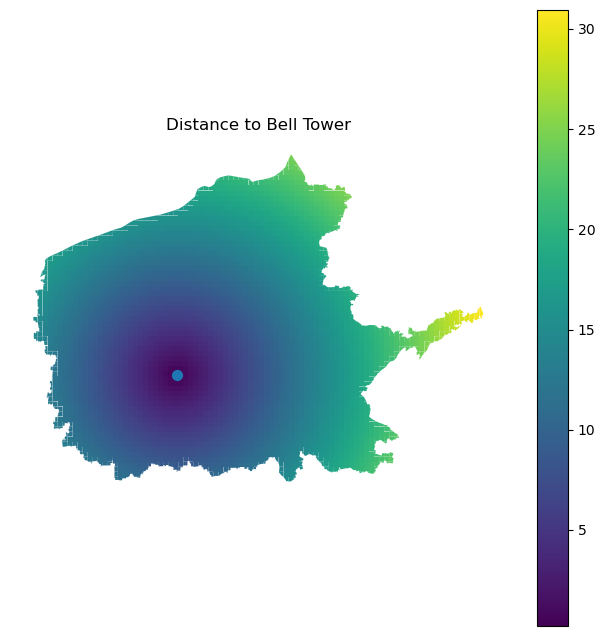

In [ ]:
# Map distance to Bell Tower

fig, ax = plt.subplots(figsize=(8, 8))

grid.plot(
    ax=ax,
    column="distance_to_bell_km",
    legend=True
)

bell.plot(
    ax=ax,
    markersize=50
)

plt.title("Distance to Bell Tower")
plt.axis("off")
plt.show()

In [ ]:
# Select central Xi'an grids within 5 km from Bell Tower

central_grid = grid[grid["distance_to_bell_km"] <= 5].copy()

print("Original grid cells:", len(grid))
print("Central grid cells:", len(central_grid))
print("Minimum distance to Bell Tower (km):", central_grid["distance_to_bell_km"].min())
print("Maximum distance to Bell Tower (km):", central_grid["distance_to_bell_km"].max())
print("Cells beyond 5 km:", (central_grid["distance_to_bell_km"] > 5).sum())
print("Missing distance values:", central_grid["distance_to_bell_km"].isna().sum())

Original grid cells: 3552
Central grid cells: 315
Minimum distance to Bell Tower (km): 0.20476828112539935
Maximum distance to Bell Tower (km): 4.980354514041734
Cells beyond 5 km: 0
Missing distance values: 0


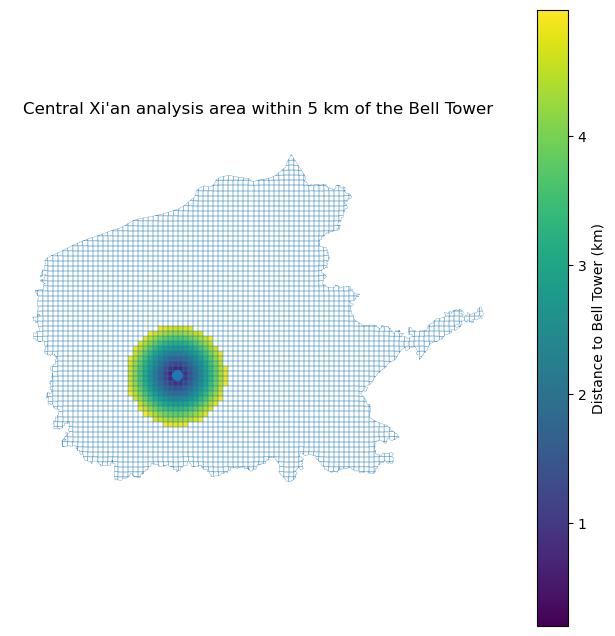

In [ ]:
# Map central analysis area

fig, ax = plt.subplots(figsize=(8, 8))

grid.boundary.plot(
    ax=ax,
    linewidth=0.2
)

central_grid.plot(
    ax=ax,
    column="distance_to_bell_km",
    legend=True,
    legend_kwds={"label": "Distance to Bell Tower (km)"}
)

bell.plot(
    ax=ax,
    markersize=50
)

ax.set_title("Central Xi'an analysis area within 5 km of the Bell Tower")
ax.set_axis_off()

plt.show()

## 3. Collect and clean commercial POI data

Commercial POIs were sourced via the Amap Web Service API (Amap Open Platform, n.d.), using three type codes: catering (050000), shopping (060000) and life services (070000). To avoid redundant API requests, the raw results have been saved as xian_commercial_poi_raw.csv. POI data are useful for mapping commercial patterns, but it may miss informal shops or businesses not listed on online platforms (Lin et al., 2025).

In [6]:
# Set Amap API key

AMAP_KEY = "PASTE_YOUR_AMAP_KEY_HERE"
# Replace this placeholder with a valid Amap API key before running the POI collection section.

In [ ]:
# Define commercial POI categories

# These three categories are used to represent common commercial activities.
commercial_types = {
    "catering": "050000",
    "shopping": "060000",
    "life_service": "070000"
}

In [8]:
# Import packages for API requests

import requests
import time

In [ ]:
# Define POI collection function

def get_pois_one_grid(grid_row, commercial_types, max_page=20):
    
    results = []
    
    one_grid = gpd.GeoDataFrame(
        [grid_row],
        geometry="geometry",
        crs=central_grid.crs
    )
    
    one_grid_wgs = one_grid.to_crs(epsg=4326)
    minx, miny, maxx, maxy = one_grid_wgs.total_bounds
    polygon = f"{minx},{miny}|{maxx},{maxy}"
    
    query_grid_id = grid_row["grid_id"]
    
    for category, type_code in commercial_types.items():
        
        for page in range(1, max_page + 1):
            
            params = {
                "key": AMAP_KEY,
                "polygon": polygon,
                "types": type_code,
                "offset": 25,
                "page": page,
                "extensions": "base",
                "output": "json"
            }
            
            r = requests.get(
                "https://restapi.amap.com/v3/place/polygon",
                params=params
            )
            
            d = r.json()
            
            if d.get("status") != "1":
                print("API request failed:", d.get("info"), "grid:", query_grid_id)
                break
            
            pois = d.get("pois", [])
            
            if len(pois) == 0:
                break
            
            for poi in pois:
                poi["category"] = category
                poi["query_grid_id"] = query_grid_id
                poi["page"] = page
                results.append(poi)
            
            time.sleep(0.2)
    
    return results

### Optional: collect POI data from the Amap API

The code cell below is reserved as an API collection template. In the final notebook, it will not be executed, because repeated requests may lead to quota issues and increase the risk of API key exposure.Therefore, later analysis will use the saved raw file `xian_commercial_poi_raw.csv`, which was generated by the same workflow.

In [10]:
# Optional: collect POI data from the Amap API
# This cell is disabled in the final notebook.
# The analysis below reads the saved file: xian_commercial_poi_raw.csv

RUN_API_COLLECTION = False

if RUN_API_COLLECTION:
    
    print("API collection is enabled. This may take a long time.")
    
    all_results = []
    
    for i, row in central_grid.iterrows():
        grid_results = get_pois_one_grid(row, commercial_types)
        all_results.extend(grid_results)
        
        print("Finished grid:", row["grid_id"], "POIs:", len(grid_results))
    
    all_pois_df = pd.DataFrame(all_results)
    all_pois_df.to_csv("xian_commercial_poi_raw.csv", index=False)
    
    print("Saved raw POI records:", len(all_pois_df))

else:
    print("API collection is disabled. The notebook will read the saved POI CSV file.")

API collection is disabled. The notebook will read the saved POI CSV file.


In [ ]:
# Read saved raw POI data

all_pois_df = pd.read_csv("xian_commercial_poi_raw.csv")

required_cols = ["id", "category", "query_grid_id", "location"]
missing_cols = [col for col in required_cols if col not in all_pois_df.columns]

print("Raw data shape:", all_pois_df.shape)
print("Missing required columns:", missing_cols)

print("Total raw records:", len(all_pois_df))
print("Unique POI IDs:", all_pois_df["id"].nunique())
print("Duplicated POI ID records:", all_pois_df.duplicated(subset=["id"]).sum())
print("Unique POI-category pairs:", all_pois_df[["id", "category"]].drop_duplicates().shape[0])
print("Query grids with returned POIs:", all_pois_df["query_grid_id"].nunique())

print("Missing ID values:", all_pois_df["id"].isna().sum())
print("Missing category values:", all_pois_df["category"].isna().sum())
print("Missing location values:", all_pois_df["location"].isna().sum())

all_pois_df[required_cols].head()

Raw data shape: (58249, 30)
Missing required columns: []
Total raw records: 58249
Unique POI IDs: 54913
Duplicated POI ID records: 3336
Unique POI-category pairs: 55564
Query grids with returned POIs: 311
Missing ID values: 0
Missing category values: 0
Missing location values: 0


,id,category,query_grid_id,location
0,B0M6ZU1RYL,catering,388,"108.968244,34.223047"
1,B0KDPS45IV,catering,388,"108.970448,34.222130"
2,B0K2A1RF3B,catering,388,"108.970602,34.222311"
3,B0L15H0II6,catering,388,"108.970384,34.222159"
4,B0K6ZZR9E5,catering,388,"108.970310,34.222757"


### Clean and convert POI records

Duplicate POIs were removed by unique POI ID because repeated grid queries can return the same business. The `location` field was split into longitude and latitude, then converted to a GeoDataFrame. Category maps remain descriptive because some POIs may appear in more than one category. Amap coordinates may use GCJ-02 rather than standard WGS84, so minor spatial offset remains a limitation.

In [ ]:
# Clean and convert raw POI records

pois_clean = all_pois_df.dropna(subset=["id", "location"]).copy()
pois_clean = pois_clean.drop_duplicates(subset=["id"]).copy()

pois_clean[["lon", "lat"]] = pois_clean["location"].str.split(",", expand=True)

pois_clean["lon"] = pd.to_numeric(pois_clean["lon"], errors="coerce")
pois_clean["lat"] = pd.to_numeric(pois_clean["lat"], errors="coerce")

pois_clean = pois_clean.dropna(subset=["lon", "lat"]).copy()

pois_gdf = gpd.GeoDataFrame(
    pois_clean,
    geometry=gpd.points_from_xy(pois_clean["lon"], pois_clean["lat"]),
    crs="EPSG:4326"
)

pois_gdf = pois_gdf.to_crs(epsg=32649)

print("Clean POI records:", len(pois_gdf))
print("Missing geometries:", pois_gdf.geometry.isna().sum())

pois_gdf[["id", "category", "lon", "lat", "geometry"]].head()

Clean POI records: 54913
Missing geometries: 0


,id,category,lon,lat,geometry
0,B0M6ZU1RYL,catering,108.968244,34.223047,POINT (312849.035 3788754.149)
1,B0KDPS45IV,catering,108.970448,34.222130,POINT (313050.056 3788648.397)
2,B0K2A1RF3B,catering,108.970602,34.222311,POINT (313064.644 3788668.189)
3,B0L15H0II6,catering,108.970384,34.222159,POINT (313044.224 3788651.731)
4,B0K6ZZR9E5,catering,108.970310,34.222757,POINT (313038.728 3788718.19)


In [ ]:
# Check cleaned POI GeoDataFrame

print("Number of cleaned POI records:", len(pois_gdf))
print("POI CRS:", pois_gdf.crs)
print("Missing POI geometries:", pois_gdf.geometry.isna().sum())
print("Invalid POI geometries:", (~pois_gdf.is_valid).sum())

pois_gdf[["id", "category", "lon", "lat", "geometry"]].head()

Number of cleaned POI records: 54913
POI CRS: EPSG:32649
Missing POI geometries: 0
Invalid POI geometries: 0


,id,category,lon,lat,geometry
0,B0M6ZU1RYL,catering,108.968244,34.223047,POINT (312849.035 3788754.149)
1,B0KDPS45IV,catering,108.970448,34.222130,POINT (313050.056 3788648.397)
2,B0K2A1RF3B,catering,108.970602,34.222311,POINT (313064.644 3788668.189)
3,B0L15H0II6,catering,108.970384,34.222159,POINT (313044.224 3788651.731)
4,B0K6ZZR9E5,catering,108.970310,34.222757,POINT (313038.728 3788718.19)


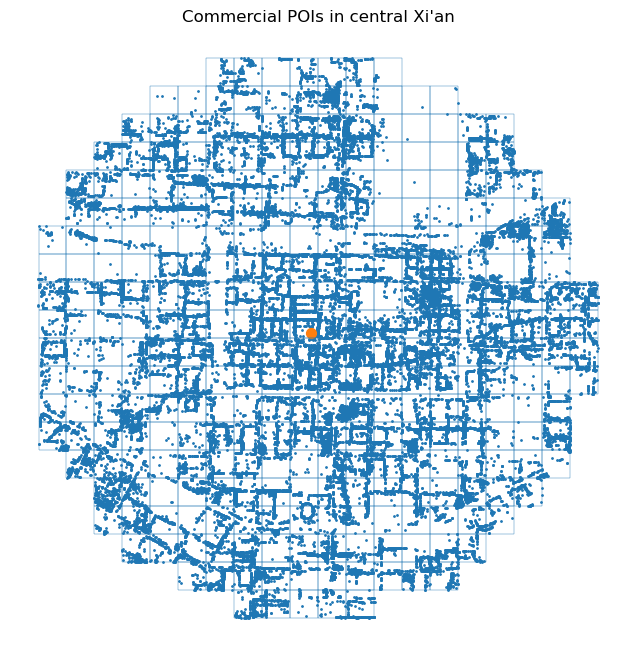

In [ ]:
# Map cleaned POIs

fig, ax = plt.subplots(figsize=(8, 8))

central_grid.boundary.plot(
    ax=ax,
    linewidth=0.3
)

pois_gdf.plot(
    ax=ax,
    markersize=1
)

bell.plot(
    ax=ax,
    markersize=50
)

plt.title("Commercial POIs in central Xi'an")
plt.axis("off")
plt.show()

### Join POIs to the 500m grid

Cleaned POIs were spatially joined to the 500m central grid. A left join first identified unmatched points. Only POIs matched to a central grid cell were kept for grid-level analysis.

In [ ]:
# Spatial join POIs to central grid

central_grid_join = central_grid[["grid_id", "geometry"]].copy()
central_grid_join = central_grid_join.rename(columns={"grid_id": "final_grid_id"})

pois_joined_check = gpd.sjoin(
    pois_gdf,
    central_grid_join,
    how="left",
    predicate="within"
)

pois_outside = pois_joined_check[pois_joined_check["final_grid_id"].isna()].copy()
pois_joined = pois_joined_check[pois_joined_check["final_grid_id"].notna()].copy()

pois_joined["final_grid_id"] = pois_joined["final_grid_id"].astype(int)

outside_share = round(len(pois_outside) / len(pois_gdf) * 100, 2)

print("POI records before spatial join:", len(pois_gdf))
print("POI records matched to central grid:", len(pois_joined))
print("POI records outside central grid:", len(pois_outside))
print("Share outside central grid (%):", outside_share)
print("Final grid cells with POIs:", pois_joined["final_grid_id"].nunique())

pois_joined[["id", "category", "query_grid_id", "final_grid_id"]].head()

POI records before spatial join: 54913
POI records matched to central grid: 54827
POI records outside central grid: 86
Share outside central grid (%): 0.16
Final grid cells with POIs: 310


,id,category,query_grid_id,final_grid_id
0,B0M6ZU1RYL,catering,388,388
1,B0KDPS45IV,catering,388,388
2,B0K2A1RF3B,catering,388,388
3,B0L15H0II6,catering,388,388
4,B0K6ZZR9E5,catering,388,388


The spatial join matched 54,827 of 54,913 cleaned POIs. Only 86 points (0.16%) were outside the final grid, probably due to API bounding-box effects or coordinate uncertainty. They were excluded from grid-level analysis.

### Create grid-level POI measures

POIs were aggregated to the 500m grid level. The main outcome is `poi_density`, measured as unique commercial POIs per square kilometre. Density allows commercial clustering to be compared across grid cells.

Separate counts were also calculated for catering, shopping, and life service POIs. These category counts are descriptive only. The statistical analysis uses total commercial POI density because duplicate cleaning counts each POI once.

In [ ]:
# Create grid-level POI count table

poi_total = (
    pois_joined
    .groupby("final_grid_id")["id"]
    .nunique()
    .reset_index(name="poi_total")
)

poi_by_category = (
    pois_joined
    .groupby(["final_grid_id", "category"])["id"]
    .nunique()
    .reset_index(name="poi_count")
)

poi_category_wide = (
    poi_by_category
    .pivot(index="final_grid_id", columns="category", values="poi_count")
    .fillna(0)
    .reset_index()
)

grid_poi = central_grid.copy()

grid_poi = grid_poi.merge(
    poi_total,
    left_on="grid_id",
    right_on="final_grid_id",
    how="left"
)

grid_poi = grid_poi.merge(
    poi_category_wide,
    left_on="grid_id",
    right_on="final_grid_id",
    how="left",
    suffixes=("", "_cat")
)

poi_cols = ["poi_total", "catering", "shopping", "life_service"]

for col in poi_cols:
    if col not in grid_poi.columns:
        grid_poi[col] = 0
    grid_poi[col] = grid_poi[col].fillna(0)

grid_poi["area_km2"] = grid_poi.geometry.area / 1_000_000

grid_poi["poi_density"] = grid_poi["poi_total"] / grid_poi["area_km2"]

print("Grid cells:", len(grid_poi))
print("Total matched POIs:", len(pois_joined))
print("Total POIs after grid aggregation:", int(grid_poi["poi_total"].sum()))
print("Grid cells with no POIs:", (grid_poi["poi_total"] == 0).sum())

grid_poi[[
    "grid_id",
    "poi_total",
    "catering",
    "shopping",
    "life_service",
    "poi_density"
]].head()

Grid cells: 315
Total matched POIs: 54827
Total POIs after grid aggregation: 54827
Grid cells with no POIs: 5


,grid_id,poi_total,catering,shopping,life_service,poi_density
0,388,219.0,80.0,113.0,26.0,876.0
1,390,101.0,29.0,43.0,29.0,404.0
2,391,197.0,78.0,69.0,50.0,788.0
3,392,85.0,24.0,38.0,23.0,340.0
4,393,121.0,40.0,40.0,41.0,484.0


The aggregation check confirms that 54,827 unique POIs were joined to 315 central grid cells. Five zero-POI cells are retained as valid observations. The dependent variable, `poi_density`, is calculated as `poi_total / area_km2`, so it measures unique commercial POIs per square kilometre.

### Summary statistics for POI measures

Summary statistics cover total POI count, POI density, category counts, and distance to the Bell Tower. They check the main variables before mapping and OLS, including the dependent variable distribution and the 5 km study-area restriction.

In [ ]:
# Summary of POI measures

poi_summary = grid_poi[[
    "poi_total",
    "poi_density",
    "catering",
    "shopping",
    "life_service",
    "distance_to_bell_km"
]].describe()

poi_summary

,poi_total,poi_density,catering,shopping,life_service,distance_to_bell_km
count,315.000000,315.000000,315.000000,315.000000,315.000000,315.000000
mean,174.053968,696.215873,56.406349,72.104762,45.542857,3.337580
std,131.046159,524.184636,49.298002,57.032272,37.348427,1.181474
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.204768
25%,78.500000,314.000000,18.500000,29.000000,19.000000,2.501004
50%,152.000000,608.000000,45.000000,57.000000,40.000000,3.545085
75%,247.500000,990.000000,79.000000,104.000000,59.000000,4.337929
max,606.000000,2424.000000,200.000000,218.000000,207.000000,4.980355


The summary table covers 315 grid cells. Across these cells, POI counts and POI density vary substantially, indicating uneven commercial clustering rather than a uniform spread. Catering, shopping and life service POIs all contribute to this pattern, although their shares are not identical. The distance measure also confirms that every grid cell falls within the 5 km study boundary around the Bell Tower.

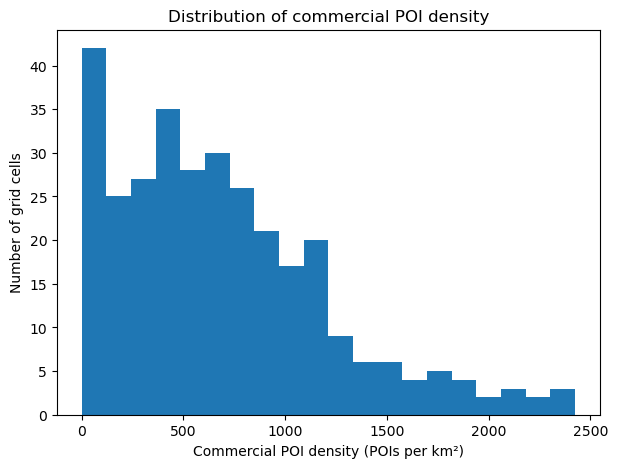

Skewness of POI density: 0.9713663174561769
Number of zero-density cells: 5


In [ ]:
# Check the distribution of POI density

plt.figure(figsize=(7, 5))

plt.hist(
    grid_poi["poi_density"],
    bins=20
)

plt.xlabel("Commercial POI density (POIs per km²)")
plt.ylabel("Number of grid cells")
plt.title("Distribution of commercial POI density")

plt.show()

print("Skewness of POI density:", grid_poi["poi_density"].skew())
print("Number of zero-density cells:", (grid_poi["poi_density"] == 0).sum())

The histogram shows a right-skewed distribution of commercial POI density, with a skewness value of 0.97. Most grid cells fall within the low to medium density range, while only a small number show very high density. Zero-density cells are limited to five grids. This pattern does not rule out OLS as an exploratory model, but it does mean that residual diagnostics and cautious interpretation are needed.

## 4. Spatial patterns of commercial POIs

This section maps total commercial POI density and category counts. The total density map is the main output because `poi_density` is the dependent variable used in the OLS models.

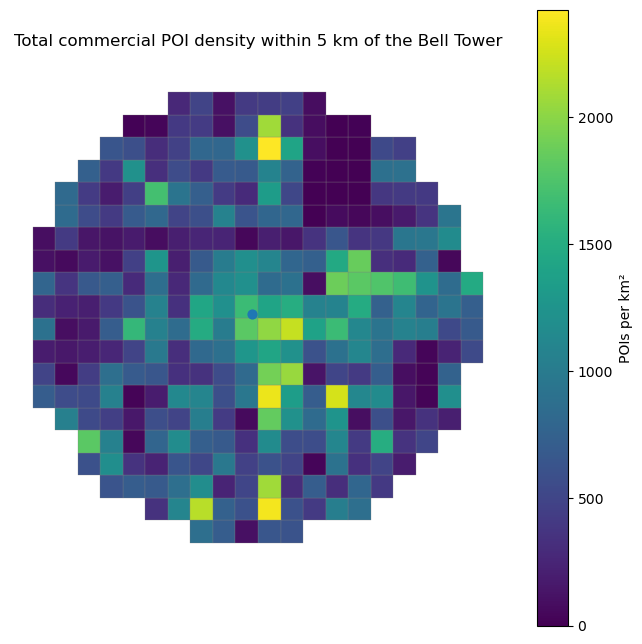

In [ ]:
# Map total commercial POI density by 500m grid

fig, ax = plt.subplots(figsize=(8, 8))

grid_poi.plot(
    ax=ax,
    column="poi_density",
    legend=True,
    edgecolor="grey",
    linewidth=0.2,
    legend_kwds={"label": "POIs per km²"}
)

bell.plot(
    ax=ax,
    markersize=40
)

ax.set_title("Total commercial POI density within 5 km of the Bell Tower")
ax.set_axis_off()

plt.show()

The POI density map shows clear clustering rather than an even distribution. This supports the later regression analysis using distance and street network variables.

### Category-specific POI patterns

The main analysis focuses on total commercial POI density. Category counts are summarised only to describe the composition of commercial activity. The three categories are catering, shopping, and life service.

These counts should be interpreted carefully because duplicate cleaning used unique POI IDs. They describe broad spatial patterns, not separate statistical claims about each sector.

In [ ]:
# Save cleaned POI and grid-level results

pois_clean.to_csv(
    "xian_commercial_poi_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

pois_joined.drop(columns="geometry").to_csv(
    "xian_commercial_poi_joined.csv",
    index=False,
    encoding="utf-8-sig"
)

grid_poi_export = grid_poi.copy()

if "centroid" in grid_poi_export.columns:
    grid_poi_export = grid_poi_export.drop(columns=["centroid"])

grid_poi_export.to_file(
    "xian_grid_poi_analysis.geojson",
    driver="GeoJSON"
)

grid_poi_export.drop(columns="geometry").to_csv(
    "xian_grid_poi_analysis.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Files saved.")
print("Grid-level records:", len(grid_poi_export))
print("Joined POI records:", len(pois_joined))

Files saved.
Grid-level records: 315
Joined POI records: 54827


In [ ]:
# Summary of POI categories

category_summary = grid_poi[[
    "catering",
    "shopping",
    "life_service"
]].sum().reset_index()

category_summary.columns = ["category", "total_count"]

category_summary["category"] = category_summary["category"].replace({
    "catering": "Catering",
    "shopping": "Shopping",
    "life_service": "Life service"
})

category_summary

,category,total_count
0,Catering,17768.0
1,Shopping,22713.0
2,Life service,14346.0


The category summary gives a simple overview of the three POI groups in the central analysis area. Differences between the three totals suggest that commercial activity is not evenly represented across categories. However, these totals should not be read as a full sectoral analysis, because the project is mainly concerned with overall commercial clustering.

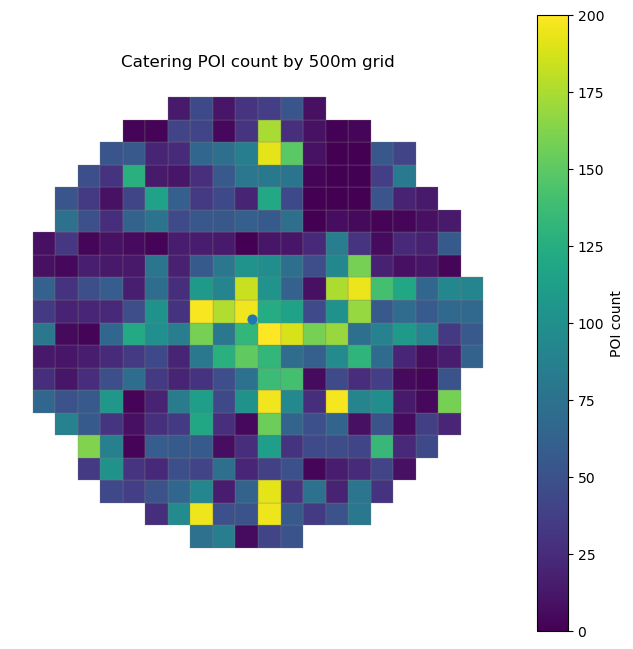

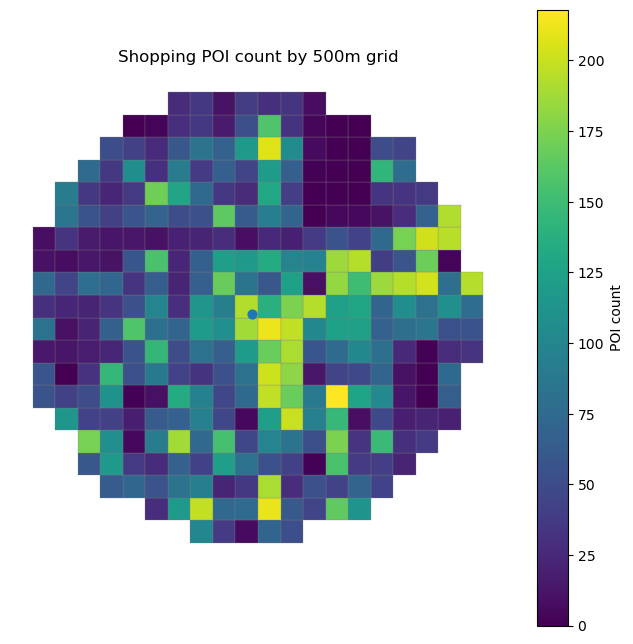

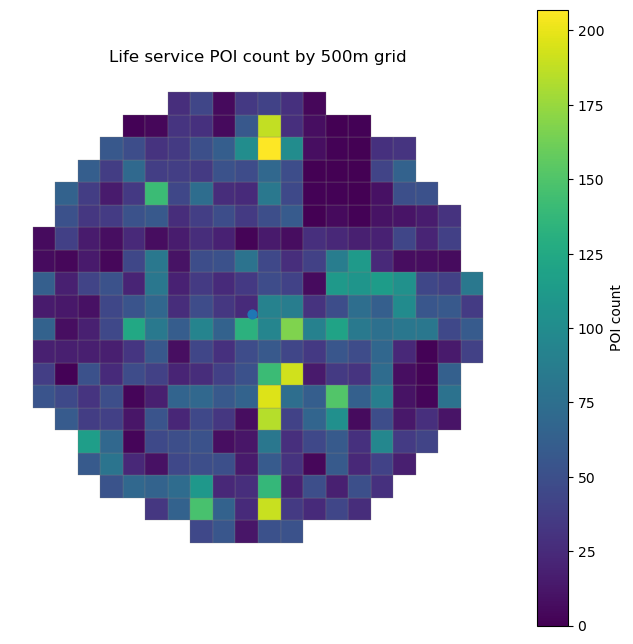

In [ ]:
# Map category-specific POI counts

category_cols = {
    "catering": "Catering POI count",
    "shopping": "Shopping POI count",
    "life_service": "Life service POI count"
}

for col, title in category_cols.items():
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    grid_poi.plot(
        ax=ax,
        column=col,
        legend=True,
        edgecolor="grey",
        linewidth=0.2,
        legend_kwds={"label": "POI count"}
    )
    
    bell.plot(
        ax=ax,
        markersize=40
    )
    
    ax.set_title(title + " by 500m grid")
    ax.set_axis_off()
    
    plt.show()

The category maps show that catering, shopping, and life service POIs all cluster centrally, with some local variation. They describe commercial composition only; the statistical analysis uses total POI density because the research questions focus on overall commercial clustering.

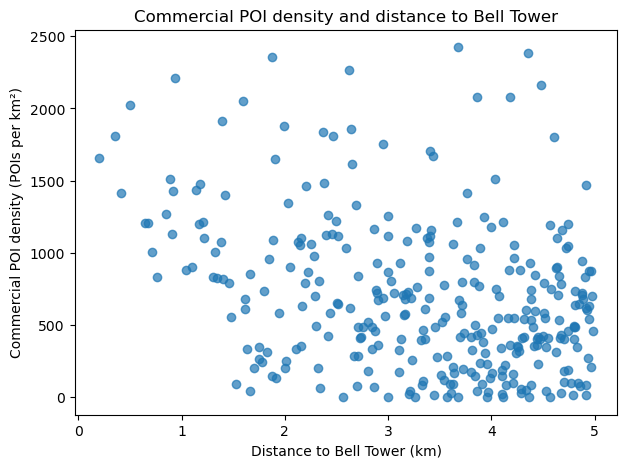

In [ ]:
# Scatter plot between distance to Bell Tower and POI density

plt.figure(figsize=(7, 5))

plt.scatter(
    grid_poi["distance_to_bell_km"],
    grid_poi["poi_density"],
    alpha=0.7
)

plt.xlabel("Distance to Bell Tower (km)")
plt.ylabel("Commercial POI density (POIs per km²)")
plt.title("Commercial POI density and distance to Bell Tower")

plt.show()

In [ ]:
# Correlation with distance to Bell Tower

corr_with_distance = grid_poi[[
    "poi_total",
    "catering",
    "shopping",
    "life_service",
    "poi_density"
]].corrwith(grid_poi["distance_to_bell_km"])

corr_with_distance = corr_with_distance.reset_index()
corr_with_distance.columns = ["variable", "correlation_with_distance"]

corr_with_distance

,variable,correlation_with_distance
0,poi_total,-0.335294
1,catering,-0.380677
2,shopping,-0.314675
3,life_service,-0.193469
4,poi_density,-0.335294


## 5. Street network and graph-based measures

This section creates grid-level street network measures. In graph terms, the street network can be understood as edges and nodes. Road segments are treated as edges, while road intersections are treated as nodes.

Three simple indicators are used. Road density measures road length per square kilometre. Intersection density measures the concentration of connected nodes. Mean intersection degree measures the average number of street segments connected to intersections within each grid cell. Similar street-network indicators are widely used to describe urban network structure (Boeing, 2022).

These variables are used to examine whether commercial POI density is associated with local street network intensity and node-level connectivity.

### Load road network data

The road network is represented using two saved GeoJSON layers: one for road edges and one for road nodes. These two layers have already been projected before this step, so metre units can be used to calculate length-based measures. Street-network data were obtained from OpenStreetMap contributors (n.d.). OpenStreetMap data are frequently used to model and analyse urban network structures, and OSMnx provides tools for acquiring and analysing these networks (Boeing, 2022, 2025). In this study, the edge layer is used to calculate the road length within each grid cell, and the node layer is used to count intersections.

In [ ]:
# Load road network files

edges = gpd.read_file("xian_drive_edges_utm.geojson")
nodes = gpd.read_file("xian_drive_nodes_utm.geojson")

edges = edges.to_crs(epsg=32649)
nodes = nodes.to_crs(epsg=32649)

print("Road edges:", len(edges))
print("Road nodes:", len(nodes))
print("Edges CRS:", edges.crs)
print("Nodes CRS:", nodes.crs)
print("Edges geometry type:", edges.geometry.geom_type.unique())
print("Nodes geometry type:", nodes.geometry.geom_type.unique())

print("Missing edge geometries:", edges.geometry.isna().sum())
print("Missing node geometries:", nodes.geometry.isna().sum())
print("Invalid edge geometries:", (~edges.is_valid).sum())
print("Invalid node geometries:", (~nodes.is_valid).sum())

print("street_count column exists:", "street_count" in nodes.columns)

if "street_count" in nodes.columns:
    print("Missing street_count values:", nodes["street_count"].isna().sum())
    print("Minimum street_count:", nodes["street_count"].min())
    print("Maximum street_count:", nodes["street_count"].max())

nodes[["street_count", "geometry"]].head()

c:\Users\Jia\anaconda3\envs\urban5160_fix\Lib\site-packages\geopandas\io\file.py:576: UserWarning: Could not parse column 'reversed' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


Road edges: 46773
Road nodes: 21520
Edges CRS: EPSG:32649
Nodes CRS: EPSG:32649
Edges geometry type: ['LineString']
Nodes geometry type: ['Point']
Missing edge geometries: 0
Missing node geometries: 0
Invalid edge geometries: 0
Invalid node geometries: 0
street_count column exists: True
Missing street_count values: 0
Minimum street_count: 1
Maximum street_count: 6


,street_count,geometry
0,3,POINT (324488.772 3798806.048)
1,4,POINT (309763.215 3790383.624)
2,3,POINT (312053.83 3789744.102)
3,5,POINT (309218.646 3793035.382)
4,3,POINT (310499.903 3792983.498)


The road network files were loaded and projected to EPSG:32649. This projected CRS is needed because road length and grid area are measured in metres. The edge layer is used for road length calculations. The node layer is used for intersection counts and mean intersection degree.

The geometry and `street_count` checks are simple validation steps. They confirm that the road edge and node data are suitable for spatial overlay, point-in-polygon operations, and node-based graph measurement.

### Calculate road density

Road density was calculated by overlaying road edges with the 500m grid. This splits road segments at grid boundaries, so each cell only receives the road length inside its own area.

Road length was measured in metres and converted into kilometres per square kilometre. This produces `road_density_km_per_km2`, an edge-based measure of local street network intensity.

In [ ]:
# Calculate road density by 500m grid

central_grid_road = central_grid[["grid_id", "geometry"]].copy()
edges_for_overlay = edges[["geometry"]].copy()

edges_grid = gpd.overlay(
    edges_for_overlay,
    central_grid_road,
    how="intersection"
)

edges_grid["road_length_m"] = edges_grid.geometry.length

road_length_by_grid = (
    edges_grid
    .groupby("grid_id")["road_length_m"]
    .sum()
    .reset_index()
)

grid_network = grid_poi.merge(
    road_length_by_grid,
    on="grid_id",
    how="left"
)

grid_network["road_length_m"] = grid_network["road_length_m"].fillna(0)

grid_network["road_density_km_per_km2"] = (
    grid_network["road_length_m"] / 1000
) / grid_network["area_km2"]

print("Grid cells:", len(grid_network))
print("Road-grid intersected features:", len(edges_grid))
print("Total road length in central grid (km):", round(grid_network["road_length_m"].sum() / 1000, 2))
print("Grid cells with zero road length:", (grid_network["road_length_m"] == 0).sum())

grid_network[["grid_id", "road_length_m", "road_density_km_per_km2"]].head()

Grid cells: 315
Road-grid intersected features: 11928
Total road length in central grid (km): 1349.13
Grid cells with zero road length: 7


,grid_id,road_length_m,road_density_km_per_km2
0,388,3718.142657,14.872571
1,390,3179.647555,12.718590
2,391,6938.457751,27.753831
3,392,3952.140342,15.808561
4,393,1447.041790,5.788167


The overlay converts road edges into a grid-level road density variable. Grid cells with no road segments are kept with road length set to zero. These are valid observations, not missing values. The final `road_density_km_per_km2` variable is used later as an edge-based street network indicator.

### Calculate intersection density and mean degree

Intersection measures were calculated from the road node layer. Nodes with `street_count >= 3` are treated as intersections. This removes simple road-end points and keeps nodes where three or more street segments meet.

The selected nodes were spatially joined to the 500m grid. Their count was divided by grid area to create `intersection_density_n_per_km2`. Their average `street_count` was also calculated as `mean_intersection_degree`, a simple graph-based measure of local node connectivity.

In [ ]:
# Calculate intersection density and mean degree by 500m grid

# Remove old intersection columns if this cell has been run before
old_cols = [
    "intersection_count",
    "intersection_density_n_per_km2",
    "mean_intersection_degree",
    "intersection_count_x",
    "intersection_count_y",
    "mean_intersection_degree_x",
    "mean_intersection_degree_y"
]

grid_network = grid_network.drop(columns=old_cols, errors="ignore")

intersections = nodes[nodes["street_count"] >= 3].copy()

central_grid_node = central_grid[["grid_id", "geometry"]].copy()

intersections_joined = gpd.sjoin(
    intersections,
    central_grid_node,
    how="inner",
    predicate="within"
)

intersection_count_by_grid = (
    intersections_joined
    .groupby("grid_id")
    .size()
    .reset_index(name="intersection_count")
)

mean_degree_by_grid = (
    intersections_joined
    .groupby("grid_id")["street_count"]
    .mean()
    .reset_index(name="mean_intersection_degree")
)

grid_network = grid_network.merge(
    intersection_count_by_grid,
    on="grid_id",
    how="left"
)

grid_network = grid_network.merge(
    mean_degree_by_grid,
    on="grid_id",
    how="left"
)

grid_network["intersection_count"] = grid_network["intersection_count"].fillna(0)
grid_network["mean_intersection_degree"] = grid_network["mean_intersection_degree"].fillna(0)

grid_network["intersection_density_n_per_km2"] = (
    grid_network["intersection_count"] / grid_network["area_km2"]
)

print("Candidate intersections:", len(intersections))
print("Intersections inside central grid:", len(intersections_joined))
print("Grid cells:", len(grid_network))
print("Grid cells with no intersections:", (grid_network["intersection_count"] == 0).sum())

grid_network[[
    "grid_id",
    "intersection_count",
    "intersection_density_n_per_km2",
    "mean_intersection_degree"
]].head()

Candidate intersections: 19458
Intersections inside central grid: 3616
Grid cells: 315
Grid cells with no intersections: 15


,grid_id,intersection_count,intersection_density_n_per_km2,mean_intersection_degree
0,388,7.0,28.0,3.000000
1,390,9.0,36.0,3.777778
2,391,20.0,80.0,3.600000
3,392,7.0,28.0,3.428571
4,393,6.0,24.0,3.833333


The node calculation converts OSMnx street nodes into grid-level indicators. Nodes with `street_count >= 3` are treated as intersections and counted within each 500m grid cell. Cells with no selected intersections are kept as zero. `intersection_density_n_per_km2` measures intersection concentration, while `mean_intersection_degree` measures average node connectivity.

### Map street network measures

Three street network variables are mapped before the statistical analysis. Road density shows edge intensity, intersection density shows node concentration, and mean intersection degree shows average node connectivity.

These maps check whether the street network indicators vary across the 5 km central area. Variables with little spatial variation would be less useful for explaining differences in commercial POI density.

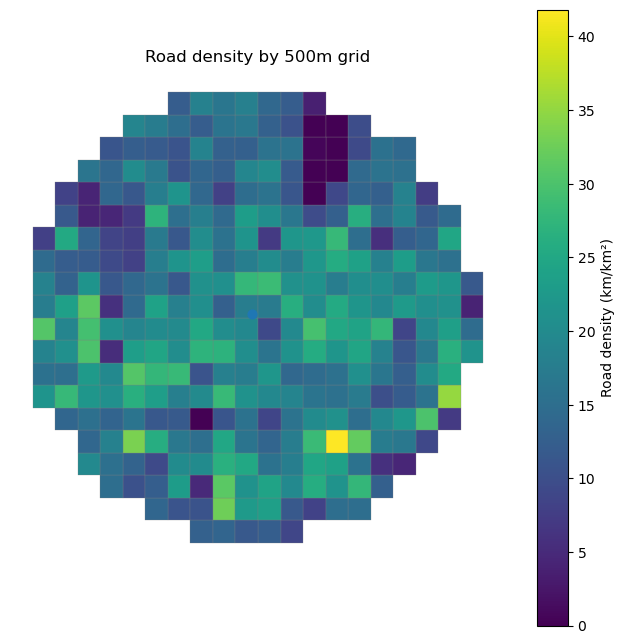

In [ ]:
# Map road density by 500m grid

fig, ax = plt.subplots(figsize=(8, 8))

grid_network.plot(
    ax=ax,
    column="road_density_km_per_km2",
    legend=True,
    edgecolor="grey",
    linewidth=0.2,
    legend_kwds={"label": "Road density (km/km²)"}
)

bell.plot(
    ax=ax,
    markersize=40
)

ax.set_title("Road density by 500m grid")
ax.set_axis_off()

plt.show()

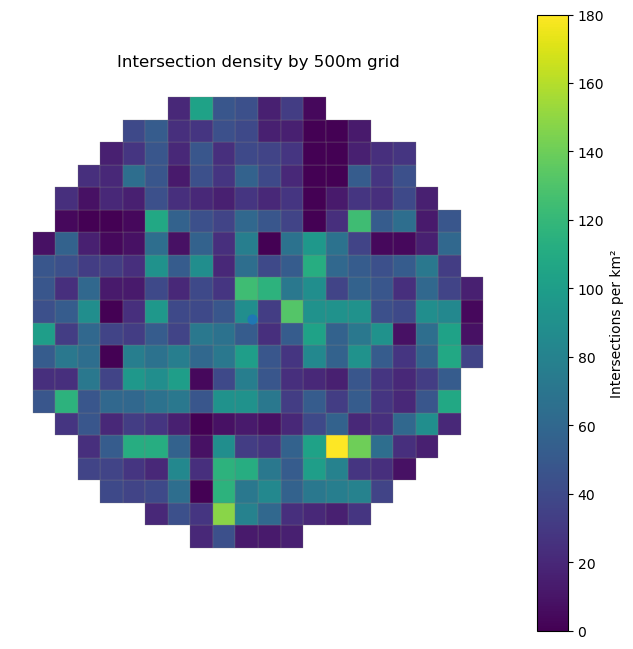

In [29]:
# Step 30: map intersection density by 500m grid

fig, ax = plt.subplots(figsize=(8, 8))

grid_network.plot(
    ax=ax,
    column="intersection_density_n_per_km2",
    legend=True,
    edgecolor="grey",
    linewidth=0.2,
    legend_kwds={"label": "Intersections per km²"}
)

bell.plot(
    ax=ax,
    markersize=40
)

ax.set_title("Intersection density by 500m grid")
ax.set_axis_off()

plt.show()

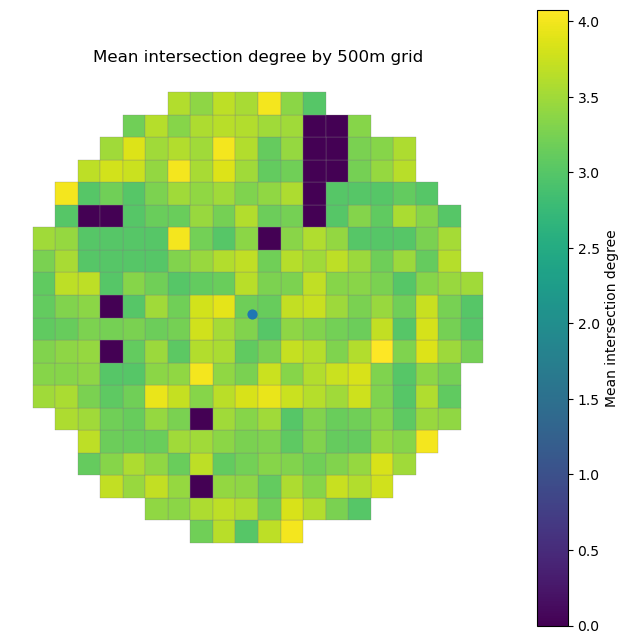

In [ ]:
# Map mean intersection degree by 500m grid

fig, ax = plt.subplots(figsize=(8, 8))

grid_network.plot(
    ax=ax,
    column="mean_intersection_degree",
    legend=True,
    edgecolor="grey",
    linewidth=0.2,
    legend_kwds={"label": "Mean intersection degree"}
)

bell.plot(
    ax=ax,
    markersize=40
)

ax.set_title("Mean intersection degree by 500m grid")
ax.set_axis_off()

plt.show()

The street network maps show that road density, intersection density, and mean intersection degree vary across central Xi'an. This supports their use in the later correlation and OLS analysis, but they remain simple grid-level indicators rather than full measures of network centrality or accessibility.

### Summary of street network variables

Summary statistics check road length, road density, intersection count, intersection density, and mean intersection degree before correlation and OLS. Following the graph materials, these are simple feature-engineered graph indicators, not GNN embeddings. Similar street-network indicators are widely used to describe urban network structure (Boeing, 2022).

A GNN is not used because the aim is to keep the predictors interpretable and link them directly to street-network structure. This is suitable for an exploratory project, where the focus is on transparent spatial associations rather than black-box prediction.

In [ ]:
# Summary of network variables

network_summary = grid_network[[
    "road_length_m",
    "road_density_km_per_km2",
    "intersection_count",
    "intersection_density_n_per_km2",
    "mean_intersection_degree"
]].describe()

network_summary

,road_length_m,road_density_km_per_km2,intersection_count,intersection_density_n_per_km2,mean_intersection_degree
count,315.000000,315.000000,315.000000,315.000000,315.000000
mean,4282.944143,17.131777,11.479365,45.917460,3.219974
std,1722.060182,6.888241,7.990961,31.963846,0.765805
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3170.660602,12.682642,6.000000,24.000000,3.142857
50%,4249.570694,16.998283,10.000000,40.000000,3.333333
75%,5368.652241,21.474609,16.000000,64.000000,3.571429
max,10456.206908,41.824828,45.000000,180.000000,4.076923


The network summary shows variation in road density, intersection density, and mean intersection degree across the central analysis area. This supports their use as explanatory variables in the correlation and OLS analysis.

These variables are simple indicators. They do not fully capture street network centrality, but they provide interpretable measures of edge intensity, node concentration, and node connectivity at the grid level.

## 6. Relationship between POI density and street network indicators

This section uses scatter plots and correlations to examine commercial POI density against distance to the Bell Tower, road density, intersection density, and mean intersection degree before fitting simple OLS models.

The aim is descriptive: to test whether denser commercial grid cells are more central or have stronger street-network intensity and node connectivity, not to infer causation.

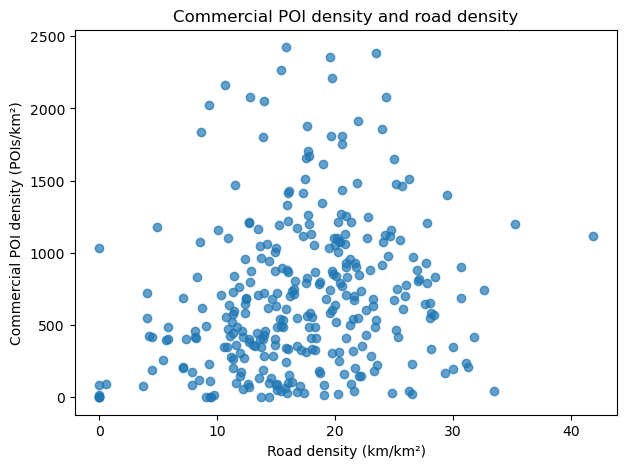

In [ ]:
# Scatter plot between POI density and road density

plt.figure(figsize=(7, 5))

plt.scatter(
    grid_network["road_density_km_per_km2"],
    grid_network["poi_density"],
    alpha=0.7
)

plt.xlabel("Road density (km/km²)")
plt.ylabel("Commercial POI density (POIs/km²)")
plt.title("Commercial POI density and road density")

plt.show()

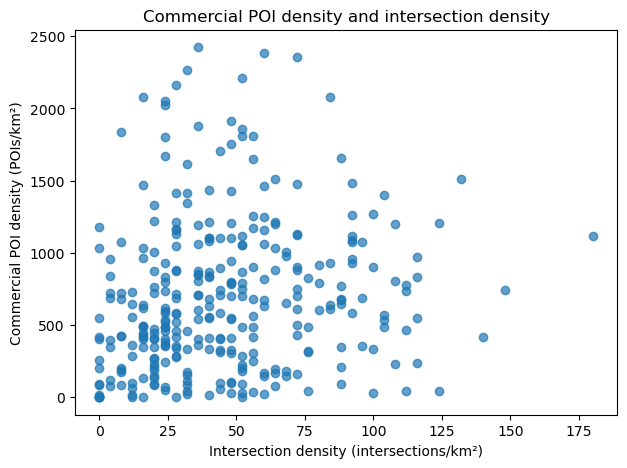

In [ ]:
# Scatter plot between POI density and intersection density

plt.figure(figsize=(7, 5))

plt.scatter(
    grid_network["intersection_density_n_per_km2"],
    grid_network["poi_density"],
    alpha=0.7
)

plt.xlabel("Intersection density (intersections/km²)")
plt.ylabel("Commercial POI density (POIs/km²)")
plt.title("Commercial POI density and intersection density")

plt.show()

In [ ]:
# Correlation table

correlation_table = grid_network[[
    "poi_density",
    "distance_to_bell_km",
    "road_density_km_per_km2",
    "intersection_density_n_per_km2",
    "mean_intersection_degree"
]].corr()

correlation_table

,poi_density,distance_to_bell_km,road_density_km_per_km2,intersection_density_n_per_km2,mean_intersection_degree
poi_density,1.000000,-0.335294,0.213272,0.161020,0.187293
distance_to_bell_km,-0.335294,1.000000,-0.243255,-0.235173,-0.029323
road_density_km_per_km2,0.213272,-0.243255,1.000000,0.843304,0.441453
intersection_density_n_per_km2,0.161020,-0.235173,0.843304,1.000000,0.316194
mean_intersection_degree,0.187293,-0.029323,0.441453,0.316194,1.000000


POI density is negatively correlated with distance to the Bell Tower (r = -0.335) and weakly positively correlated with road density (0.213), intersection density (0.161), and mean intersection degree (0.187).

Road and intersection density are strongly correlated (0.843), so VIF is needed before model interpretation. Mean intersection degree is less correlated with other network indicators, suggesting a different aspect of node connectivity.

### Multicollinearity check

Because road and intersection density are strongly correlated, VIF is used before OLS to check multicollinearity among distance to the Bell Tower, road density, intersection density, and mean intersection degree.

In [35]:
# VIF check for candidate explanatory variables

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

vif_vars = [
    "distance_to_bell_km",
    "road_density_km_per_km2",
    "intersection_density_n_per_km2",
    "mean_intersection_degree"
]

vif_data = grid_network[vif_vars].copy()

vif_data_const = sm.add_constant(vif_data)

vif_table = pd.DataFrame()
vif_table["variable"] = vif_data_const.columns
vif_table["vif"] = [
    variance_inflation_factor(vif_data_const.values, i)
    for i in range(vif_data_const.shape[1])
]

vif_table

,variable,vif
0,const,30.216287
1,distance_to_bell_km,1.073958
2,road_density_km_per_km2,3.970945
3,intersection_density_n_per_km2,3.517624
4,mean_intersection_degree,1.267965


Ignoring the constant term, all VIF values are below 5. Distance to the Bell Tower (1.074) and mean intersection degree (1.268) show low multicollinearity, while road density (3.971) and intersection density (3.518) are higher but still acceptable. Their coefficients should therefore be interpreted carefully.

## 7. OLS models

OLS models use `poi_density` as the dependent variable. The baseline includes only distance to the Bell Tower; three separate models add road density, intersection density, or mean intersection degree. A combined model is tested because VIF does not indicate severe multicollinearity. All models test exploratory spatial association, not causation.

In [ ]:
# Fit OLS models

model_baseline = smf.ols(
    "poi_density ~ distance_to_bell_km",
    data=grid_network
).fit()

model_road = smf.ols(
    "poi_density ~ distance_to_bell_km + road_density_km_per_km2",
    data=grid_network
).fit()

model_intersection = smf.ols(
    "poi_density ~ distance_to_bell_km + intersection_density_n_per_km2",
    data=grid_network
).fit()

model_degree = smf.ols(
    "poi_density ~ distance_to_bell_km + mean_intersection_degree",
    data=grid_network
).fit()

model_combined = smf.ols(
    "poi_density ~ distance_to_bell_km + road_density_km_per_km2 + intersection_density_n_per_km2 + mean_intersection_degree",
    data=grid_network
).fit()

print("OLS models fitted.")
print("Number of observations:", int(model_combined.nobs))

OLS models fitted.
Number of observations: 315


In [ ]:
# Compare OLS model fit

models = {
    "Baseline: distance only": model_baseline,
    "Road density": model_road,
    "Intersection density": model_intersection,
    "Mean intersection degree": model_degree,
    "Combined model": model_combined
}

model_comparison = pd.DataFrame({
    "model": models.keys(),
    "r_squared": [model.rsquared for model in models.values()],
    "adj_r_squared": [model.rsquared_adj for model in models.values()],
    "aic": [model.aic for model in models.values()],
    "bic": [model.bic for model in models.values()]
})

model_comparison

,model,r_squared,adj_r_squared,aic,bic
0,Baseline: distance only,0.112422,0.109586,4804.324827,4811.829973
1,Road density,0.130861,0.125289,4799.712039,4810.969757
2,Intersection density,0.119569,0.113925,4803.778182,4815.035900
3,Mean intersection degree,0.143942,0.138454,4794.935135,4806.192853
4,Combined model,0.149316,0.138339,4796.951387,4815.714250


In [ ]:
# Compare OLS coefficients

coef_rows = []

for model_name, model in models.items():
    for variable in model.params.index:
        if variable != "Intercept":
            coef_rows.append({
                "model": model_name,
                "variable": variable,
                "coef": model.params[variable],
                "p_value": model.pvalues[variable]
            })

coef_table = pd.DataFrame(coef_rows)

coef_table

,model,variable,coef,p_value
0,Baseline: distance only,distance_to_bell_km,-148.759861,1.029044e-09
1,Road density,distance_to_bell_km,-133.651015,6.568664e-08
2,Road density,road_density_km_per_km2,10.653346,1.055145e-02
3,Intersection density,distance_to_bell_km,-139.684645,2.009802e-08
4,Intersection density,intersection_density_n_per_km2,1.426378,1.125279e-01
5,Mean intersection degree,distance_to_bell_km,-146.449169,1.018210e-09
6,Mean intersection degree,mean_intersection_degree,121.574552,7.905840e-04
7,Combined model,distance_to_bell_km,-139.853104,1.578735e-08
8,Combined model,road_density_km_per_km2,10.173270,2.012700e-01
9,Combined model,intersection_density_n_per_km2,-1.156791,4.733214e-01


The OLS results show that distance to the Bell Tower is negatively associated with POI density in all models. This supports the descriptive finding that commercial POI density tends to decline farther from the central landmark.

The network indicators show different results. Road density is positive and significant in its separate model, while intersection density is positive but not significant. Mean intersection degree is positive and significant in both the separate model and the combined model. This suggests that node connectivity adds useful information beyond simple road and intersection density.

Among the tested OLS models, the mean intersection degree model performs best. It has the highest adjusted R-squared and the lowest AIC and BIC. However, this should be read as a relative comparison within a small model set, not as proof that the model fully explains commercial clustering. These results show spatial associations, not causal effects.

## 8. Residuals from the selected OLS model

The mean intersection degree model performed best among the tested OLS models. Residual checks were then used to assess whether it still left unexplained spatial patterns.

In [ ]:
# Add residuals from the selected OLS model

preferred_model = model_degree

grid_network["model_fitted"] = preferred_model.fittedvalues
grid_network["model_residual"] = preferred_model.resid

print("selected OLS model: Mean intersection degree")
print("Mean residual:", round(grid_network["model_residual"].mean(), 4))
print("Minimum residual:", round(grid_network["model_residual"].min(), 4))
print("Maximum residual:", round(grid_network["model_residual"].max(), 4))

grid_network[[
    "grid_id",
    "poi_density",
    "model_fitted",
    "model_residual"
]].head()

selected OLS model: Mean intersection degree
Mean residual: -0.0
Minimum residual: -925.623
Maximum residual: 1839.0514


,grid_id,poi_density,model_fitted,model_residual
0,388,876.0,434.008886,441.991114
1,390,404.0,550.556411,-146.556411
2,391,788.0,570.244095,217.755905
3,392,340.0,610.428437,-270.428437
4,393,484.0,614.417647,-130.417647


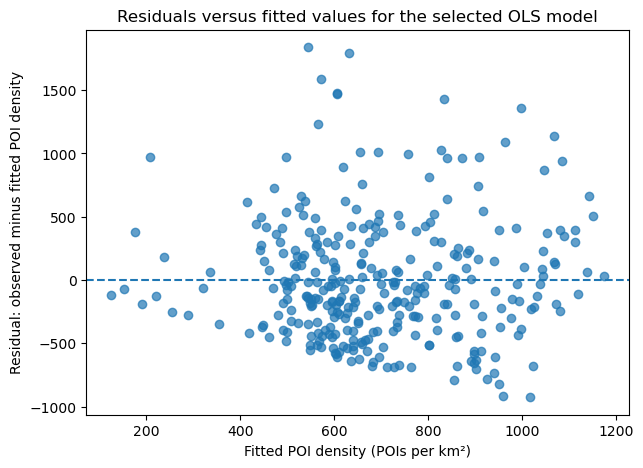

In [ ]:
# Residuals versus fitted values for selected OLS model

plt.figure(figsize=(7, 5))

plt.scatter(
    grid_network["model_fitted"],
    grid_network["model_residual"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")

plt.xlabel("Fitted POI density (POIs per km²)")
plt.ylabel("Residual: observed minus fitted POI density")
plt.title("Residuals versus fitted values for the selected OLS model")

plt.show()

The residuals are centred around zero, but the spread is still large for some fitted values. This suggests that the preferred OLS model captures part of the POI density pattern but still leaves substantial unexplained variation. The residual map below checks whether these errors also show spatial clustering.

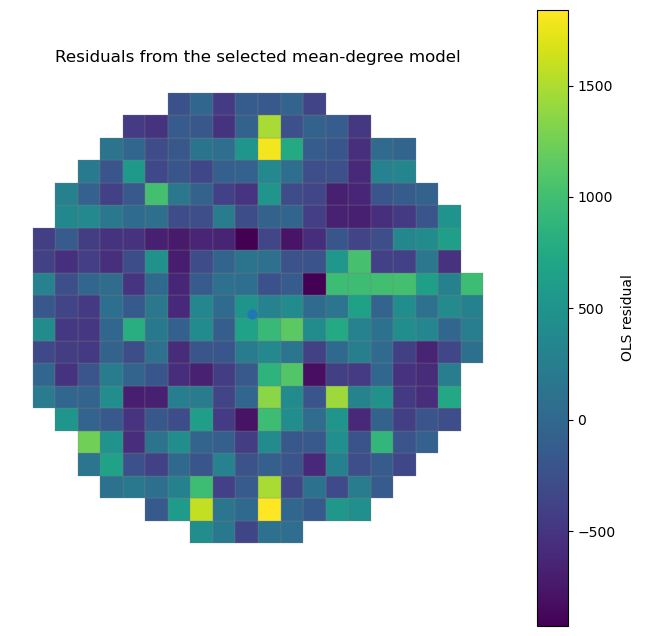

In [ ]:
# Map residuals from the selected OLS model

fig, ax = plt.subplots(figsize=(8, 8))

grid_network.plot(
    ax=ax,
    column="model_residual",
    legend=True,
    edgecolor="grey",
    linewidth=0.2,
    legend_kwds={"label": "OLS residual"}
)

bell.plot(
    ax=ax,
    markersize=40
)

ax.set_title("Residuals from the selected mean-degree model")
ax.set_axis_off()

plt.show()

The residual checks show that the selected OLS model should be interpreted with caution. The mean residual is close to zero, but some grid cells are still under- or over-predicted. The residual map suggests that unexplained errors may have spatial patterns. This may reflect omitted factors such as land use, public transport access, tourism, rent, or planning policy.

### Residual spatial autocorrelation check

A Global Moran's I test was used to check whether residuals from the preferred OLS model are spatially autocorrelated. This matters because spatial dependence can weaken standard OLS assumptions and inference (Anselin, 1988; Chen, 2023). If residuals are clustered, the model may still miss spatial processes not captured by distance to the Bell Tower and mean intersection degree.

In [ ]:
# Moran's I test for residuals

from libpysal.weights import Queen
from esda.moran import Moran

w = Queen.from_dataframe(grid_network, use_index=False)
w.transform = "r"

moran_resid = Moran(
    grid_network["model_residual"],
    w
)

print("Residual Moran's I:", round(moran_resid.I, 4))
print("p-value:", round(moran_resid.p_sim, 4))

Residual Moran's I: 0.1985
p-value: 0.001


The residual Moran's I is 0.1985, with a simulated p-value of 0.001. This indicates significant positive spatial autocorrelation in the residuals, meaning that nearby grid cells still share similar unexplained errors.

Therefore, the preferred OLS model should be interpreted as an exploratory global model. It shows useful associations between distance, street network structure, and commercial POI density, but its standard errors and p-values should be read cautiously. A spatial regression model or GWR/MGWR would be a stronger extension, but this report keeps OLS to maintain a simple and reproducible workflow.

## 9. Discussion and conclusion

This project examined commercial POI clustering in central Xi'an using 500m grid cells. POI density is uneven within the 5 km study area and generally declines with distance from the Bell Tower.

Street network effects are mixed. Road density is positive and significant in its separate model, while intersection density is not significant. Mean intersection degree performs best among the tested OLS models, suggesting that node connectivity may be more closely associated with commercial clustering than simple intersection counts.

However, the model still explains only a limited share of variation. The residual Moran's I result (0.1985, p = 0.001) shows that unexplained errors remain spatially clustered. This limits the strength of the OLS inference, even though the model is useful for exploratory comparison.

Several limitations remain. Amap POI data may contain coordinate uncertainty, the 5 km boundary is an analytical choice, and the network indicators do not measure more complex graph properties such as centrality or accessibility. The residual Moran's I test also shows remaining spatial autocorrelation, which may weaken standard OLS assumptions (Anselin, 1988; Chen, 2023). Therefore, the findings should be read as exploratory spatial associations rather than causal effects. Future work could add land use, public transport access, tourism, rent, spatial regression, or geographically weighted models (Lessani & Li, 2024).

## 10. Export final outputs

This section saves the final grid-level dataset and the updated OLS output tables.

In [ ]:
# Export final outputs

final_grid = grid_network.copy()

# GeoJSON can only save one geometry column.
# Keep the main polygon geometry and remove centroid if it exists.
if "centroid" in final_grid.columns:
    final_grid = final_grid.drop(columns=["centroid"])

final_grid = final_grid.set_geometry("geometry")

final_grid.to_file(
    "xian_final_grid_analysis.geojson",
    driver="GeoJSON"
)

final_grid.drop(columns=["geometry"]).to_csv(
    "xian_final_grid_analysis.csv",
    index=False,
    encoding="utf-8-sig"
)

model_comparison.to_csv(
    "xian_model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

coef_table.to_csv(
    "xian_coefficient_table.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Final outputs saved.")
print("Rows in final grid:", len(final_grid))
print("Files saved:")
print("- xian_final_grid_analysis.geojson")
print("- xian_final_grid_analysis.csv")
print("- xian_model_comparison.csv")
print("- xian_coefficient_table.csv")

Final outputs saved.
Rows in final grid: 315
Files saved:
- xian_final_grid_analysis.geojson
- xian_final_grid_analysis.csv
- xian_model_comparison.csv
- xian_coefficient_table.csv


In [ ]:
# Final summary of key variables

final_grid[[
    "poi_total",
    "poi_density",
    "distance_to_bell_km",
    "road_density_km_per_km2",
    "intersection_density_n_per_km2",
    "model_residual"
]].describe()

,poi_total,poi_density,distance_to_bell_km,road_density_km_per_km2,intersection_density_n_per_km2,model_residual
count,315.000000,315.000000,315.000000,315.000000,315.000000,3.150000e+02
mean,174.053968,696.215873,3.337580,17.131777,45.917460,-9.470294e-13
std,131.046159,524.184636,1.181474,6.888241,31.963846,4.849936e+02
min,0.000000,0.000000,0.204768,0.000000,0.000000,-9.256230e+02
25%,78.500000,314.000000,2.501004,12.682642,24.000000,-3.436221e+02
50%,152.000000,608.000000,3.545085,16.998283,40.000000,-6.936466e+01
75%,247.500000,990.000000,4.337929,21.474609,64.000000,2.736213e+02
max,606.000000,2424.000000,4.980355,41.824828,180.000000,1.839051e+03


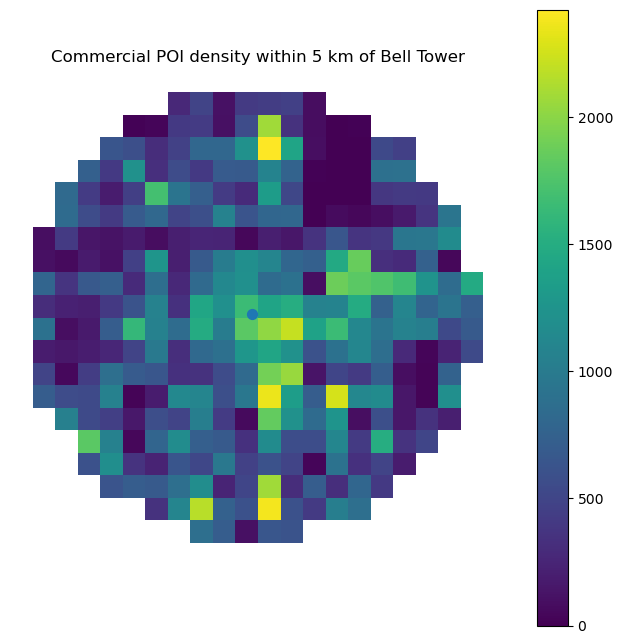

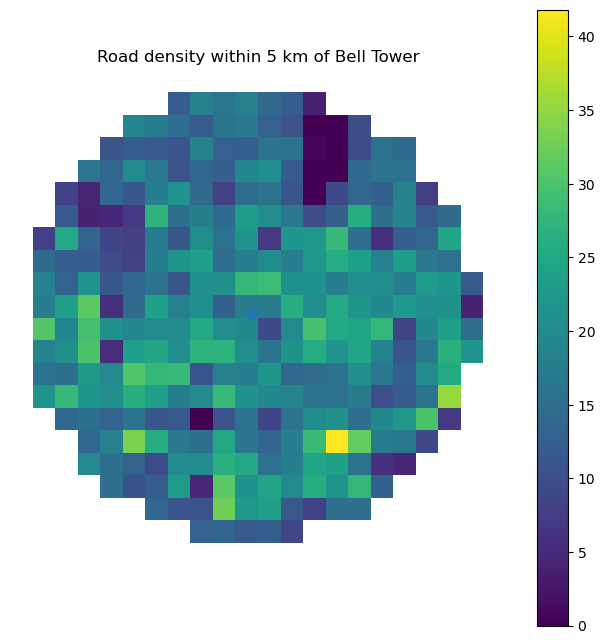

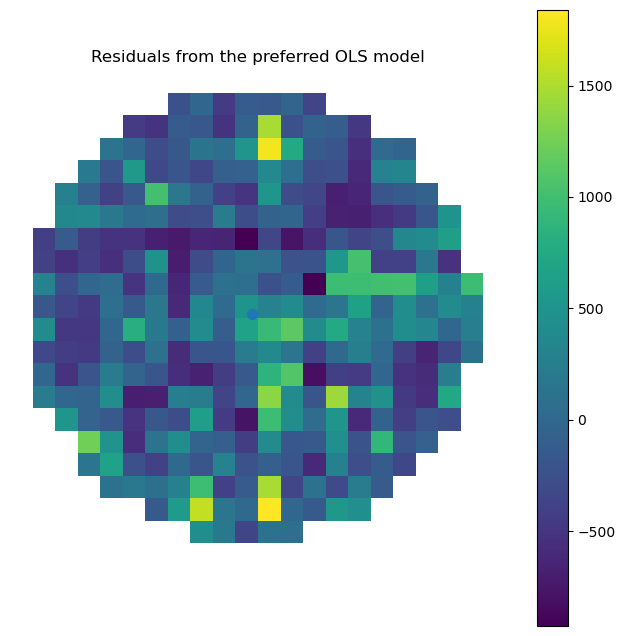

In [ ]:
# Save key figures as PNG files

fig, ax = plt.subplots(figsize=(8, 8))
final_grid.plot(ax=ax, column="poi_density", legend=True)
bell.plot(ax=ax, markersize=50)
plt.title("Commercial POI density within 5 km of Bell Tower")
plt.axis("off")
plt.savefig("fig_poi_density.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
final_grid.plot(ax=ax, column="road_density_km_per_km2", legend=True)
bell.plot(ax=ax, markersize=50)
plt.title("Road density within 5 km of Bell Tower")
plt.axis("off")
plt.savefig("fig_road_density.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
final_grid.plot(ax=ax, column="model_residual", legend=True)
bell.plot(ax=ax, markersize=50)
plt.title("Residuals from the preferred OLS model")
plt.axis("off")
plt.savefig("fig_model_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Check final output files

import os

final_files = [
    "xian_commercial_poi_raw.csv",
    "xian_commercial_poi_clean.csv",
    "xian_commercial_poi_joined.csv",
    "xian_final_grid_analysis.geojson",
    "xian_final_grid_analysis.csv",
    "xian_model_comparison.csv",
    "xian_coefficient_table.csv",
    "fig_poi_density.png",
    "fig_road_density.png",
    "fig_model_residuals.png"
]

for file in final_files:
    print(file, os.path.exists(file))

xian_commercial_poi_raw.csv True
xian_commercial_poi_clean.csv True
xian_commercial_poi_joined.csv True
xian_final_grid_analysis.geojson True
xian_final_grid_analysis.csv True
xian_model_comparison.csv True
xian_coefficient_table.csv True
fig_poi_density.png True
fig_road_density.png True
fig_model_residuals.png True


## References

Anselin, L. (1988). *Spatial econometrics: Methods and models*. Kluwer Academic Publishers. doi:10.1007/978-94-015-7799-1

Amap Open Platform. (n.d.). Web Service API documentation. Retrieved May 28, 2026, from the Amap Open Platform website.https://lbs.amap.com/api

Boeing, G. (2022). Street network models and indicators for every urban area in the world. *Geographical Analysis, 54*(3), 519–535. doi:10.1111/gean.12281

Boeing, G. (2025). Modeling and analyzing urban networks and amenities with OSMnx. *Geographical Analysis, 57*(4), 567–577. doi:10.1111/gean.70009

Chen, Y. (2023). Spatial autocorrelation equation based on Moran’s index. *Scientific Reports, 13*, Article 19296. doi:10.1038/s41598-023-45947-x

Lessani, M. N., & Li, Z. (2024). SGWR: Similarity and geographically weighted regression. *International Journal of Geographical Information Science, 38*(7), 1232–1255. doi:10.1080/13658816.2024.2342319

Lin, X., Yang, T., & Law, S. (2025). From points to patterns: An explorative POI network study on urban functional distribution. *Computers, Environment and Urban Systems, 117*, Article 102246. doi:10.1016/j.compenvurbsys.2024.102246

OpenStreetMap contributors. (n.d.). OpenStreetMap data [Data set]. OpenStreetMap Foundation. Retrieved May 28, 2026, from the OpenStreetMap website.https://www.openstreetmap.org/#map=19/34.261010/108.942340

Shi, X., Liu, D., & Gan, J. (2024). A study on the relationship between road network centrality and the spatial distribution of commercial facilities: A case of Changchun, China. *Sustainability, 16*(10), Article 3920. doi:10.3390/su16103920